In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------
# CONFIG (ONSHORE WIND ATB 2024)
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ons-wind_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ons-wind_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ons-wind_ATB_2024_conservative.csv",
}

# Your file has multiple turbine classes (e.g., 115hh_170rd, etc.).
# Set to None to run all; or set to one string to run one turbine.
TURBINE_FILTER = None  # e.g., "115hh_170rd"

COL_TURBINE = "Turbine"
COL_YEAR = "Year"

METRICS = [
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
    "Var O&M $/MWh",
]

START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "ons_wind_envelope_multipliers.csv"

# ---------------------------
# NEW CONFIG (sampling)
# ---------------------------
# Var O&M is constant in this file, so we do NOT sample it.
SAMPLE_METRICS = [
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
]

# Multiplication occurs AFTER 2025  => apply to Year > 2025
APPLY_AFTER_YEAR = 2025

# how many sampled files to generate
N_SAMPLES = 2

# reproducibility
RANDOM_SEED = 42

# output folder
OUT_DIR = Path("ons_wind_ATB_2024_samples")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# also save sampled multipliers table
SAVE_SAMPLES_TABLE = True
SAMPLES_TABLE_CSV = OUT_DIR / "ons_wind_ATB_2024_sample_multipliers.csv"


# ---------------------------
# HELPERS (same style as your UPV notebook)
# ---------------------------
def _clean_url(url: str) -> str:
    return url.split("#")[0]

def load_from_urls(file_urls: dict) -> pd.DataFrame:
    frames = []
    for scen, url in file_urls.items():
        url = _clean_url(url)
        tmp = pd.read_csv(url)
        tmp["scenario"] = scen
        frames.append(tmp)

    out = pd.concat(frames, ignore_index=True)

    # Basic typing
    out[COL_YEAR] = pd.to_numeric(out[COL_YEAR], errors="coerce")
    out[COL_TURBINE] = out[COL_TURBINE].astype(str)

    for col in METRICS:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    return out.sort_values(["scenario", COL_TURBINE, COL_YEAR]).reset_index(drop=True)

def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    """
    Least-squares multiplier m minimizing || m*moderate - target ||^2
    => m = (moderate·target) / (moderate·moderate)
    """
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers_for_group(df_g: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    """
    df_g is already filtered to ONE turbine group.
    Returns low/high multipliers that scale MODERATE to span ADV/CONS.
    """
    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           # pivot_table is safer than pivot if duplicates exist
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"])

    if len(window) < 2:
        return {
            "metric": metric,
            "low_mult": np.nan,
            "high_mult": np.nan,
            "mA": np.nan,
            "mC": np.nan,
            "n_years_fit": len(window),
            "fit_year_min": (window.index.min() if len(window) else np.nan),
            "fit_year_max": (window.index.max() if len(window) else np.nan),
        }

    mA = fit_multiplier_ls(window["moderate"], window["advanced"])
    mC = fit_multiplier_ls(window["moderate"], window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))

    return {
        "metric": metric,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "mA": mA,
        "mC": mC,
        "n_years_fit": len(window),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope_for_group(df_g: pd.DataFrame, turb: str, metric: str, start_year: int = 2025) -> dict:
    info = envelope_multipliers_for_group(df_g, metric, start_year=start_year)

    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (\u2265 {start_year})"
    )
    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")
    plt.title(f"Onshore Wind ATB 2024 \u2014 {turb} \u2014 {metric}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return info


# ---------------------------
# NEW: sampling helpers
# ---------------------------
def build_base_moderate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns the MODERATE case for all turbines in GitHub format:
    Turbine,Year,CF_mult,Overnight Cap Cost $/kW,Fixed O&M $/(kW-yr),Var O&M $/MWh
    """
    base = (df[df["scenario"] == "moderate"][[COL_TURBINE, COL_YEAR] + METRICS]
            .dropna(subset=[COL_TURBINE, COL_YEAR])
            .sort_values([COL_TURBINE, COL_YEAR])
            .reset_index(drop=True))
    # exact output order
    base = base[[COL_TURBINE, COL_YEAR] + METRICS]
    return base

def sample_uniform(lo: float, hi: float, rng: np.random.Generator) -> float:
    return float(rng.uniform(float(lo), float(hi)))

def apply_multipliers_after_year_for_turbine(base_turb: pd.DataFrame, mults: dict, apply_after_year: int) -> pd.DataFrame:
    """
    Applies metric multipliers to one turbine slice only where Year > apply_after_year.
    """
    out = base_turb.copy()
    mask = out[COL_YEAR].astype(int) > int(apply_after_year)

    for metric, mult in mults.items():
        out.loc[mask, metric] = out.loc[mask, metric] * float(mult)

    return out

# ---------------------------
# NEW: Plot a sampled case
# ---------------------------

def plot_sampled_metric(sampled_df: pd.DataFrame, original_df: pd.DataFrame, turbine: str, metric: str, apply_after_year: int):
    """
    Plots a specific metric for a given turbine from the sampled data
    against the original moderate scenario.
    """
    # Filter original moderate data
    original_moderate_data = original_df[
        (original_df[COL_TURBINE] == turbine) & (original_df["scenario"] == "moderate")
    ][[COL_YEAR, metric]].set_index(COL_YEAR)

    # Filter sampled data
    sampled_turbine_data = sampled_df[
        (sampled_df[COL_TURBINE] == turbine)
    ][[COL_YEAR, metric]].set_index(COL_YEAR)

    plt.figure(figsize=(10, 5))
    plt.plot(original_moderate_data.index, original_moderate_data[metric].values, label="Original Moderate", linewidth=2.2)
    plt.plot(sampled_turbine_data.index, sampled_turbine_data[metric].values, label="Sampled", linestyle='--', linewidth=2.2)

    # Highlight the application year
    plt.axvline(x=apply_after_year, color='r', linestyle=':', label=f"Multipliers applied after {apply_after_year}")

    plt.title(f"Onshore Wind ATB 2024 \u2014 {turbine} \u2014 {metric} (Sampled vs. Original Moderate)")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()





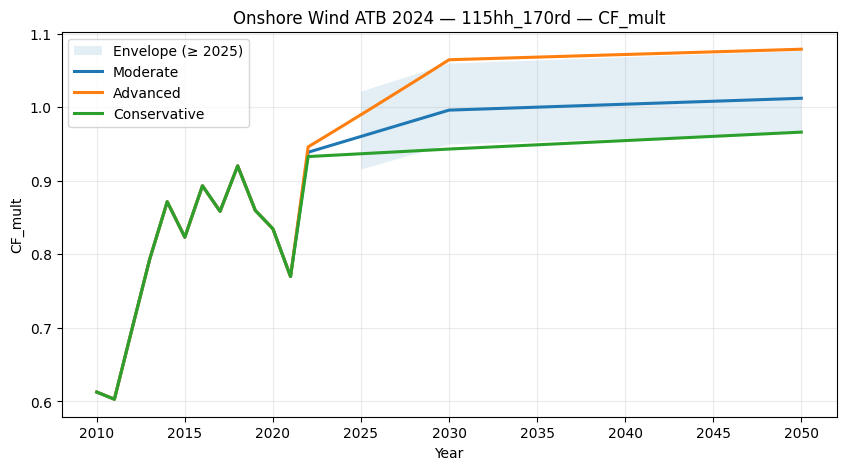

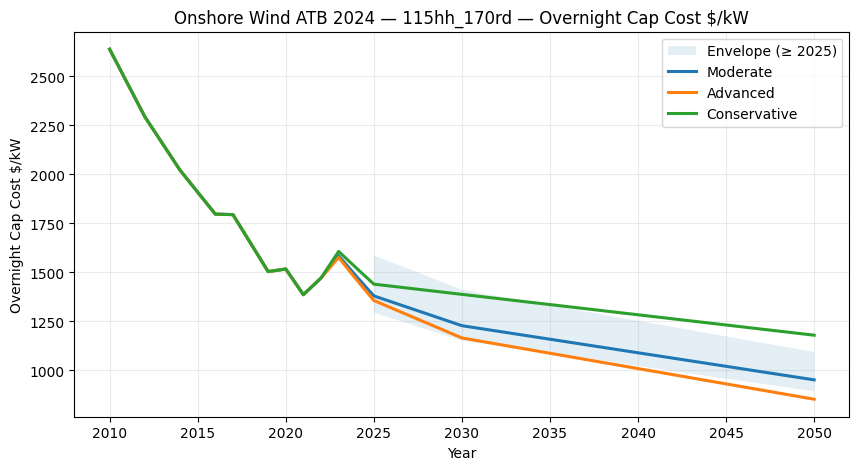

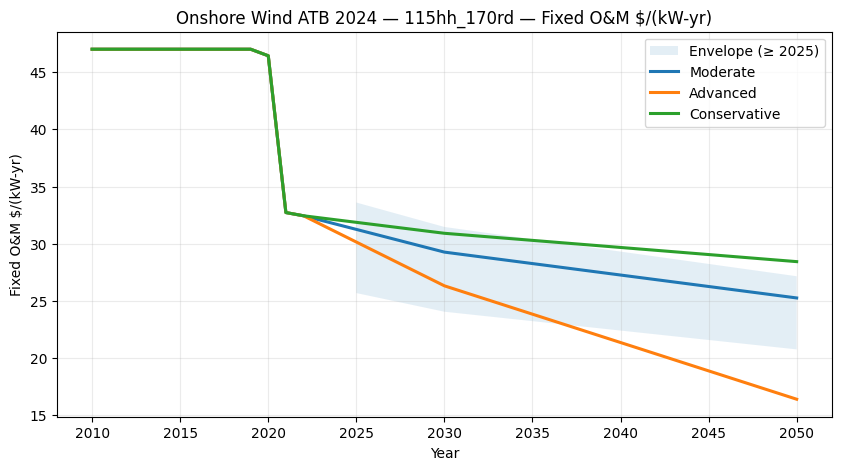

/tmp/ipython-input-660077285.py:131: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-660077285.py:132: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


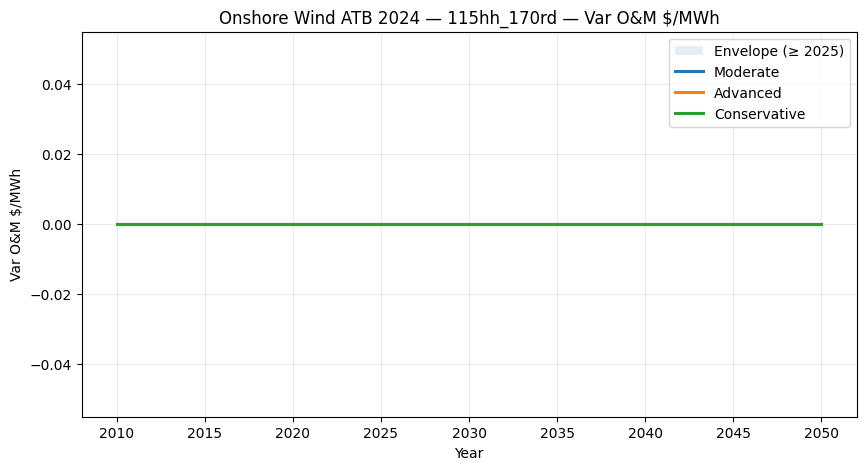

,Turbine,metric,low_mult,high_mult,mA,mC,n_years_fit,fit_year_min,fit_year_max
0,115hh_170rd,CF_mult,0.953130,1.063435,1.063435,0.953130,26,2025,2050
1,115hh_170rd,Overnight Cap Cost $/kW,0.938408,1.149475,0.938408,1.149475,26,2025,2050
2,115hh_170rd,Fixed O&M $/(kW-yr),0.821770,1.075217,0.821770,1.075217,26,2025,2050
3,115hh_170rd,Var O&M $/MWh,NaN,NaN,NaN,NaN,26,2025,2050


Saved: ons_wind_envelope_multipliers.csv
First 10 sampled multiplier records:
{'sample_id': 0, 'Turbine': '115hh_170rd', 'apply_after_year': 2025, 'CF_mult_mult': 1.0385015149073538, 'Overnight Cap Cost $/kW_mult': 1.0310404880955966, 'Fixed O&M $/(kW-yr)_mult': 1.0393789855110251}
{'sample_id': 1, 'Turbine': '115hh_170rd', 'apply_after_year': 2025, 'CF_mult_mult': 1.0300534047726617, 'Overnight Cap Cost $/kW_mult': 0.9582855166537274, 'Fixed O&M $/(kW-yr)_mult': 1.069038460847183}
Saved: ons_wind_ATB_2024_samples/ons_wind_ATB_2024_sample_multipliers.csv
Saved 2 sampled CSV files to: /content/ons_wind_ATB_2024_samples


In [2]:
# ---------------------------
# RUN: envelope + multipliers
# ---------------------------
df = load_from_urls(FILE_URLS)

# turbine list
if TURBINE_FILTER is None:
    turbines = sorted(df[COL_TURBINE].dropna().unique().tolist())
else:
    turbines = [str(TURBINE_FILTER)]

rows = []
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    for metric in METRICS:
        info = plot_with_envelope_for_group(df_g, turb, metric, start_year=START_YEAR)
        rows.append({"Turbine": turb, **info})

res = pd.DataFrame(rows)
display(res)

if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)


# ---------------------------
# NEW: Generate sampled ONS wind CSVs (GitHub format)
# ---------------------------
# Build envelope bounds dict: (turbine, metric) -> {low_mult, high_mult, ...}
env_bounds = {}
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    for metric in SAMPLE_METRICS:
        env_bounds[(turb, metric)] = envelope_multipliers_for_group(df_g, metric, start_year=START_YEAR)

# Base moderate table (all turbines)
base = build_base_moderate(df)

rng = np.random.default_rng(RANDOM_SEED)

# list-format record of sampled multipliers (long format)
samples_list = []

for k in range(N_SAMPLES):
    sampled_frames = []

    for turb in turbines:
        base_turb = base[base[COL_TURBINE] == turb].copy()

        # sample one multiplier per metric, per turbine
        mults = {}
        for metric in SAMPLE_METRICS:
            info = env_bounds[(turb, metric)]
            lo, hi = info["low_mult"], info["high_mult"]

            # if bounds are missing (NaN), fall back to 1.0 (no change)
            if pd.isna(lo) or pd.isna(hi):
                mults[metric] = 1.0
            else:
                mults[metric] = sample_uniform(lo, hi, rng)

        sampled_turb = apply_multipliers_after_year_for_turbine(
            base_turb=base_turb,
            mults=mults,
            apply_after_year=APPLY_AFTER_YEAR
        )

        sampled_frames.append(sampled_turb)

        # record multipliers (list format)
        samples_list.append({
            "sample_id": k,
            "Turbine": turb,
            "apply_after_year": APPLY_AFTER_YEAR,
            **{f"{m}_mult": mults[m] for m in SAMPLE_METRICS},
        })

    sampled_all = pd.concat(sampled_frames, ignore_index=True)
    sampled_all = sampled_all[[COL_TURBINE, COL_YEAR] + METRICS]  # enforce exact order

    out_path = OUT_DIR / f"ons-wind_ATB_2024_sample_{k:03d}.csv"
    sampled_all.to_csv(out_path, index=False)

# Show “list format” preview (first 10 records)
print("First 10 sampled multiplier records:")
for item in samples_list[:10]:
    print(item)

if SAVE_SAMPLES_TABLE:
    samples_table = pd.DataFrame(samples_list)
    samples_table.to_csv(SAMPLES_TABLE_CSV, index=False)
    print("Saved:", SAMPLES_TABLE_CSV)

print(f"Saved {N_SAMPLES} sampled CSV files to: {OUT_DIR.resolve()}")



Plotting metrics for sample 0 and turbine 115hh_170rd:


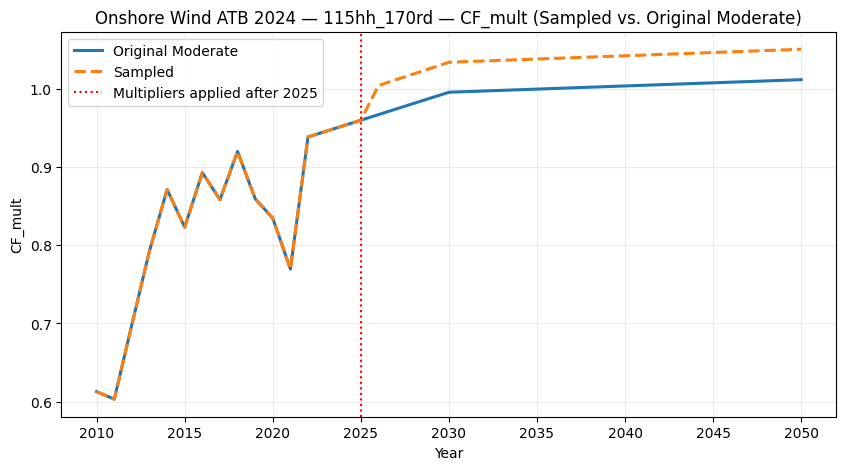

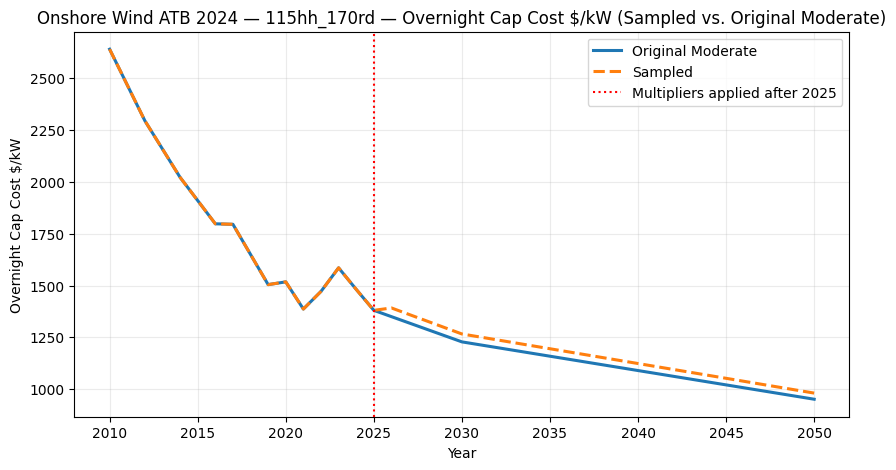

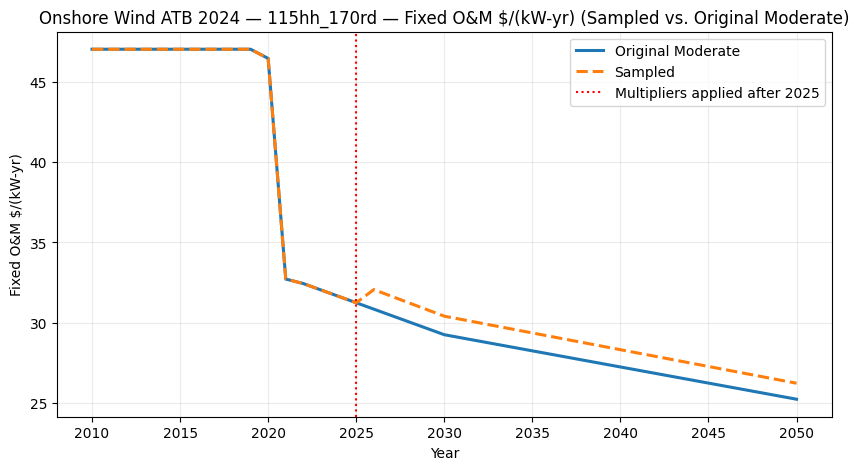

In [3]:
# Choose one sample to plot (e.g., the first one, k=0)
sample_to_plot_idx = 0
sample_to_plot_path = OUT_DIR / f"ons-wind_ATB_2024_sample_{sample_to_plot_idx:03d}.csv"
sampled_df_for_plot = pd.read_csv(sample_to_plot_path)

# Assuming only one turbine for simplicity, or pick the first one if multiple
turbine_to_plot = turbines[0] # turbines variable already defined in the notebook

print(f"\nPlotting metrics for sample {sample_to_plot_idx} and turbine {turbine_to_plot}:")
for metric_to_plot in SAMPLE_METRICS:
    plot_sampled_metric(
        sampled_df=sampled_df_for_plot,
        original_df=df, # df variable already loaded with all scenarios
        turbine=turbine_to_plot,
        metric=metric_to_plot,
        apply_after_year=APPLY_AFTER_YEAR
    )

In [4]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
metric_units = {
    "CF_mult": r"unitless",
    "Overnight Cap Cost $/kW": r"\$/kW",
    "Fixed O&M $/(kW-yr)": r"\$/kW-yr",
}
label_map = {"115hh_170rd": "Onshore wind"}
SAMPLE_METRICS = ["CF_mult", "Overnight Cap Cost $/kW", "Fixed O&M $/(kW-yr)"]

latex_rows = []

latex_rows = []
for turb in turbines:
    turb_label = label_map.get(turb, turb)  # rename only if it matches
    for metric in SAMPLE_METRICS:
        info = env_bounds[(turb, metric)]
        low_mult = info["low_mult"]
        high_mult = info["high_mult"]
        unit = metric_units.get(metric, "unitless")

        parameter = rf"{turb_label} -- {metric}"
        latex_rows.append(rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\")

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Onshore Wind ATB 2024}}
\label{{tab:ons_wind_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Onshore Wind ATB 2024}
\label{tab:ons_wind_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Onshore wind -- CF_mult & 1.0634 & 0.9531 & unitless (multiplier) \\
Onshore wind -- Overnight Cap Cost $/kW & 1.1495 & 0.9384 & \$/kW (multiplier) \\
Onshore wind -- Fixed O&M $/(kW-yr) & 1.0752 & 0.8218 & \$/kW-yr (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
START_YEAR = 2025
APPLY_STRICTLY_AFTER = True   # True => Year > 2025, False => Year >= 2025

OUT_DIR = Path("ons_wind_ATB_2024_morris")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your GitHub raw links
MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# NREL/ReEDS base file (moderate)
ONS_REF_URL = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ons-wind_ATB_2024_moderate.csv#/"

# -----------------------------
# 1) Load Morris inputs
# -----------------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

PARAM_COL  = pick_col(factor_map, ["parameter","Parameter","name","Name","desc","description"])
FACTOR_COL = pick_col(factor_map, ["factor","Factor","id","ID"])
if PARAM_COL is None or FACTOR_COL is None:
    raise ValueError(f"Can't find parameter/factor columns in factor_map. Columns: {list(factor_map.columns)}")

def get_factor_id(param_exact: str) -> str:
    hit = factor_map.loc[factor_map[PARAM_COL].astype(str).str.strip() == param_exact]
    if hit.empty:
        raise ValueError(f"Could not find '{param_exact}' in factor_map[{PARAM_COL}]")
    return str(hit.iloc[0][FACTOR_COL])

# Resolve factor IDs from factor_map (these are the design column names)
factor_cf   = get_factor_id("Onshore wind -- CF_mult")
factor_cap  = get_factor_id("Onshore wind -- Overnight Cap Cost $/kW")
factor_fom  = get_factor_id("Onshore wind -- Fixed O&M $/(kW-yr)")

for f in [factor_cf, factor_cap, factor_fom]:
    if f not in design.columns:
        raise ValueError(f"Design file is missing column '{f}'. Found columns: {list(design.columns)[:40]} ...")

# -----------------------------
# 2) Load base NREL file and enforce exact ReEDS schema
# -----------------------------
base = pd.read_csv(ONS_REF_URL)

REQ_COLS = [
    "Turbine",
    "Year",
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
    "Var O&M $/MWh",
]
missing = [c for c in REQ_COLS if c not in base.columns]
if missing:
    raise ValueError(f"Base file missing columns {missing}. Found: {list(base.columns)}")

# Keep EXACT column order and names
base = base[REQ_COLS].copy()
base["Year"] = base["Year"].astype(int)

# Year mask (apply multipliers only after / from threshold)
if APPLY_STRICTLY_AFTER:
    year_mask = base["Year"] > int(START_YEAR)
else:
    year_mask = base["Year"] >= int(START_YEAR)

# -----------------------------
# 3) Generate one CSV per Morris run
# -----------------------------
written = []
for run_idx, row in design.iterrows():
    df_out = base.copy()

    # Multipliers for this run
    m_cf  = float(row[factor_cf])
    m_cap = float(row[factor_cap])
    m_fom = float(row[factor_fom])

    # Apply only for selected years
    df_out.loc[year_mask, "CF_mult"] = df_out.loc[year_mask, "CF_mult"].astype(float) * m_cf
    df_out.loc[year_mask, "Overnight Cap Cost $/kW"] = df_out.loc[year_mask, "Overnight Cap Cost $/kW"].astype(float) * m_cap
    df_out.loc[year_mask, "Fixed O&M $/(kW-yr)"] = df_out.loc[year_mask, "Fixed O&M $/(kW-yr)"].astype(float) * m_fom

    # IMPORTANT: keep exact column order
    df_out = df_out[REQ_COLS]

    fp = OUT_DIR / f"ons-wind_ATB_2024_morris_{run_idx:03d}.csv"
    df_out.to_csv(fp, index=False)
    written.append({
        "run_id": run_idx,
        "file": fp.name,
        "cf_mult": m_cf,
        "capcost_mult": m_cap,
        "fom_mult": m_fom,
        "year_rule": ("> 2025" if APPLY_STRICTLY_AFTER else ">= 2025"),
    })

# Manifest (handy for debugging / traceability)
manifest = pd.DataFrame(written)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)

print(f"Done. Wrote {len(written)} CSVs to: {OUT_DIR.resolve()}")
print("Manifest:", (OUT_DIR / "manifest.csv").resolve())
print("\nPreview first file:")
print(pd.read_csv(OUT_DIR / "ons-wind_ATB_2024_morris_000.csv").head(10).to_string(index=False))


Done. Wrote 200 CSVs to: /content/ons_wind_ATB_2024_morris
Manifest: /content/ons_wind_ATB_2024_morris/manifest.csv

Preview first file:
    Turbine  Year  CF_mult  Overnight Cap Cost $/kW  Fixed O&M $/(kW-yr)  Var O&M $/MWh
115hh_170rd  2010  0.61277               2639.12325             47.01292            0.0
115hh_170rd  2011  0.60304               2466.78385             47.01292            0.0
115hh_170rd  2012  0.69848               2294.44446             47.01292            0.0
115hh_170rd  2013  0.79294               2157.98645             47.01292            0.0
115hh_170rd  2014  0.87144               2021.52845             47.01292            0.0
115hh_170rd  2015  0.82324               1909.53503             47.01292            0.0
115hh_170rd  2016  0.89312               1797.54161             47.01292            0.0
115hh_170rd  2017  0.85843               1795.05224             47.01292            0.0
115hh_170rd  2018  0.92017               1649.67472             47.0129

In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("ons_wind_ATB_2024_morris")  # <- must match your script
zip_name = "ons-wind_ATB_2024_morris"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: ons-wind_ATB_2024_morris.zip
